In [1]:
from pyspark.sql import SparkSession

#Starting Entry Point
spark = SparkSession.builder \
    .appName("NYC Taxi") \
    .master("local[*]") \
    .getOrCreate()


In [2]:
#Libraries needed
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql.window import Window

In [32]:
weather1=spark.read.json("hdfs:///user/student/raw_uber/weather")

In [33]:
weather1.show()

+---------+------------------+--------------------+--------------------+---------+---------+----------------+---------------------+------------------+
|elevation| generationtime_ms|              hourly|        hourly_units| latitude|longitude|        timezone|timezone_abbreviation|utc_offset_seconds|
+---------+------------------+--------------------+--------------------+---------+---------+----------------+---------------------+------------------+
|     32.0|18.558382987976074|{[0.0, 0.0, 0.0, ...|{mm, cm, °C, iso8...|40.738136|-74.04254|America/New_York|                GMT-4|            -14400|
|     32.0| 6.603002548217773|{[0.0, 0.0, 0.0, ...|{mm, cm, °C, iso8...|40.738136|-74.04254|America/New_York|                GMT-4|            -14400|
+---------+------------------+--------------------+--------------------+---------+---------+----------------+---------------------+------------------+



In [34]:
weather_final = weather1.select(
    "latitude",
    "longitude",
    "timezone",
    explode(
        arrays_zip(
            col("hourly.time"),
            col("hourly.temperature_2m"),
            col("hourly.precipitation"),
            col("hourly.snowfall")
        )
    ).alias("weather")
).select(
    "latitude",
    "longitude",
    "timezone",
    col("weather.0").alias("time"),
    col("weather.1").alias("temperature_2m"),
    col("weather.2").alias("precipitation"),
    col("weather.3").alias("snowfall")
)

In [35]:
weather_final.show()

+---------+---------+----------------+----------------+--------------+-------------+--------+
| latitude|longitude|        timezone|            time|temperature_2m|precipitation|snowfall|
+---------+---------+----------------+----------------+--------------+-------------+--------+
|40.738136|-74.04254|America/New_York|2025-12-01T00:00|           4.0|          0.0|     0.0|
|40.738136|-74.04254|America/New_York|2025-12-01T01:00|           3.9|          0.0|     0.0|
|40.738136|-74.04254|America/New_York|2025-12-01T02:00|           3.7|          0.0|     0.0|
|40.738136|-74.04254|America/New_York|2025-12-01T03:00|           3.0|          0.0|     0.0|
|40.738136|-74.04254|America/New_York|2025-12-01T04:00|           2.7|          0.0|     0.0|
|40.738136|-74.04254|America/New_York|2025-12-01T05:00|           2.4|          0.0|     0.0|
|40.738136|-74.04254|America/New_York|2025-12-01T06:00|           2.3|          0.0|     0.0|
|40.738136|-74.04254|America/New_York|2025-12-01T07:00|     

In [36]:
weather_final = weather_final.withColumn(
    "time",
    to_timestamp(col("time"), "yyyy-MM-dd'T'HH:mm")
)\
    .withColumn(
        "Date",
        to_date(col("time"), "yyyy-MM-dd'T'HH:mm")
    )\
        .withColumn(
    "hour",
    hour("time")
)

In [37]:
weathercleaned1= weather_final.filter(col('Date') == '2025-12-01')


In [38]:
weathercleaned2=weather_final.filter(col('Date') == '2026-01-01')

In [39]:
weather_cleaned = weathercleaned1.unionByName(
    weathercleaned2
)

In [40]:
weather_cleaned = (
    weather_cleaned
    .withColumn("year", year(col("Date")))
    .withColumn("month", month(col("Date")))
    .withColumn("day", dayofmonth(col("Date")))
)
weather_cleaned.drop('Date')

DataFrame[latitude: double, longitude: double, timezone: string, time: timestamp, temperature_2m: double, precipitation: double, snowfall: double, hour: int, year: int, month: int, day: int]

In [41]:
weather_Cleaned= weather_cleaned.drop("time")\
.drop('Date')

In [45]:
weather_Cleaned.show()

+---------+---------+----------------+--------------+-------------+--------+----+----+-----+---+
| latitude|longitude|        timezone|temperature_2m|precipitation|snowfall|hour|year|month|day|
+---------+---------+----------------+--------------+-------------+--------+----+----+-----+---+
|40.738136|-74.04254|America/New_York|           4.0|          0.0|     0.0|   0|2025|   12|  1|
|40.738136|-74.04254|America/New_York|           3.9|          0.0|     0.0|   1|2025|   12|  1|
|40.738136|-74.04254|America/New_York|           3.7|          0.0|     0.0|   2|2025|   12|  1|
|40.738136|-74.04254|America/New_York|           3.0|          0.0|     0.0|   3|2025|   12|  1|
|40.738136|-74.04254|America/New_York|           2.7|          0.0|     0.0|   4|2025|   12|  1|
|40.738136|-74.04254|America/New_York|           2.4|          0.0|     0.0|   5|2025|   12|  1|
|40.738136|-74.04254|America/New_York|           2.3|          0.0|     0.0|   6|2025|   12|  1|
|40.738136|-74.04254|America/N

In [29]:
#Reading Data
taxi_zone = spark.read.csv(r'hdfs:///user/student/raw_uber/lookup',
inferSchema = True,
header= True)
tripdata_2025 = spark.read.parquet(r'hdfs:///user/student/raw_uber/trip2025')
tripdata_2026 = spark.read.parquet(r'hdfs:///user/student/raw_uber/trip2026')

In [30]:
taxi_zone.show(truncate=False)

+----------+-------------+-----------------------+------------+
|LocationID|Borough      |Zone                   |service_zone|
+----------+-------------+-----------------------+------------+
|1         |EWR          |Newark Airport         |EWR         |
|2         |Queens       |Jamaica Bay            |Boro Zone   |
|3         |Bronx        |Allerton/Pelham Gardens|Boro Zone   |
|4         |Manhattan    |Alphabet City          |Yellow Zone |
|5         |Staten Island|Arden Heights          |Boro Zone   |
|6         |Staten Island|Arrochar/Fort Wadsworth|Boro Zone   |
|7         |Queens       |Astoria                |Boro Zone   |
|8         |Queens       |Astoria Park           |Boro Zone   |
|9         |Queens       |Auburndale             |Boro Zone   |
|10        |Queens       |Baisley Park           |Boro Zone   |
|11        |Brooklyn     |Bath Beach             |Boro Zone   |
|12        |Manhattan    |Battery Park           |Yellow Zone |
|13        |Manhattan    |Battery Park C

In [31]:
tripdata_2025.show(truncate=False)

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|request_datetime   |on_scene_datetime  |pickup_datetime    |dropoff_datetime   |PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|bcf |sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+-------

In [17]:
tripdata_2026.show(truncate=False)

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|request_datetime   |on_scene_datetime  |pickup_datetime    |dropoff_datetime   |PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|bcf |sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+-------

In [18]:
tripdata_2026.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp (nullable = true)
 |-- on_scene_datetime: timestamp (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_ride_flag: strin

In [19]:
tripdata_2025.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp (nullable = true)
 |-- on_scene_datetime: timestamp (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_ride_flag: strin

In [20]:
taxi_zone.printSchema()

root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)



In [16]:
#Check Null values for each column
tripdata_2026.select([
    sum(col(c).isNull().cast('int')).alias(c)
    for c in tripdata_2026.columns
]).show()


+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|request_datetime|on_scene_datetime|pickup_datetime|dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+---

In [17]:
tripdata_2025.select([
    sum(col(c).isNull().cast('int')).alias(c)
    for c in tripdata_2025.columns
]).show()


+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|request_datetime|on_scene_datetime|pickup_datetime|dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+---

In [12]:
taxi_zone.select([
    sum(col(c).isNull().cast('int')).alias(c)
    for c in taxi_zone.columns
]).show()


+----------+-------+----+------------+
|LocationID|Borough|Zone|service_zone|
+----------+-------+----+------------+
|         0|      0|   0|           0|
+----------+-------+----+------------+



In [18]:
null_counts = tripdata_2025.select(
    count(when(col("originating_base_num").isNull(), 1)).alias("null_count"),
    count(when(col("originating_base_num").isNotNull(), 1)).alias("not_null_count")
)
pdf = null_counts.toPandas()

In [19]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.2 MB 1.1 MB/s eta 0:00:01:24��█████████████████▌          | 6.2 MB 141 kB/s eta 0:00:22███████       | 7.2 MB 141 kB/s eta 0:00:15
     |████████████████████████████████| 4.4 MB 1.1 MB/s eta 0:00:01��████████▏      | 3.5 MB 1.1 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 275 kB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 38 kB/s  eta 0:00:0125 kB/s eta 0:00:09
You should consider upgrading via the '/usr/local/bin/python3.8 -m pip install --upgrade pip' command.


Matplotlib is building the font cache; this may take a moment.


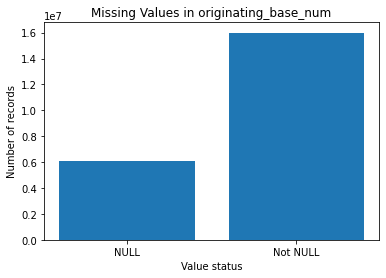

In [20]:
#Simple visualization to show how many nulls in one column
import matplotlib.pyplot as plt

values = [
    pdf["null_count"][0],
    pdf["not_null_count"][0]
]

labels = ["NULL", "Not NULL"]


plt.bar(labels, values)
plt.title("Missing Values in originating_base_num")
plt.xlabel("Value status")
plt.ylabel("Number of records")

plt.show()

In [21]:
#Drop Duplicates
tripdata_2025Cleaned = tripdata_2025.dropDuplicates([
    "hvfhs_license_num",
    "request_datetime",
    "pickup_datetime",
    "dropoff_datetime",
    "PULocationID",
    "DOLocationID"
])
tripdata_2026Cleaned=tripdata_2026.dropDuplicates([
  "hvfhs_license_num",
      "request_datetime",
      "pickup_datetime",
      "dropoff_datetime",
      "PULocationID",
      "DOLocationID"  
])

In [22]:
tripdata_2025Cleaned= tripdata_2025.fillna({
 'originating_base_num': "Unknown"
})
tripdata_2026Cleaned=tripdata_2026.fillna({
 'originating_base_num': "Unknown"
})

In [20]:
tripdata_2025Cleaned.show()

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+-------

In [24]:
#Checking any duplicates
original_count = tripdata_2025.count()
cleaned_count = tripdata_2025Cleaned.count()

print("Original:", original_count)
print("Cleaned:", cleaned_count)
print("Removed:", original_count - cleaned_count)

Original: 22108438
Cleaned: 22108438
Removed: 0


In [25]:
tripdata_2025Cleaned.filter(
    col("base_passenger_fare") < 0
).count()

3020

In [23]:
taxi_zoneCleaned=taxi_zone.dropDuplicates(["LocationID"])

In [24]:
tripdata_cleaned = tripdata_2025Cleaned.unionByName(
    tripdata_2026Cleaned
)

In [12]:
tripdata_cleaned.show()

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+-------

In [25]:
tripdata_Cleaned=tripdata_cleaned.dropDuplicates()

In [14]:
tripdata_Cleaned.filter(
    col("base_passenger_fare") < 0
).count()

2026-09-02 07:04:35,505 WARN util.package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


32985

In [24]:
tripdata_Cleaned=tripdata_Cleaned.withColumn('is_Paid',
                                                when(col("base_passenger_fare") < 0, "Refunded")
                                                .otherwise("Paid"))

In [26]:
datetime_cols = [
    "pickup_datetime",
    "dropoff_datetime"
]

for col_name in datetime_cols:
    tripdata_Cleaned = (
        tripdata_Cleaned
        .withColumn(f"{col_name}_year", year(col(col_name)))
        .withColumn(f"{col_name}_month", month(col(col_name)))
        .withColumn(f"{col_name}_day", dayofmonth(col(col_name)))
        .withColumn(f"{col_name}_hour", hour(col(col_name)))
        .withColumn(f"{col_name}_minute", minute(col(col_name)))
        .withColumn(f"{col_name}_second", second(col(col_name)))
    )

In [25]:
tripdata_Cleaned.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = false)
 |-- request_datetime: timestamp (nullable = true)
 |-- on_scene_datetime: timestamp (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_ride_flag: stri

In [29]:
tripdata_Cleaned.write \
    .mode("overwrite") \
    .option("compression", "snappy") \
    .parquet("hdfs:///user/student/cleanedUber/trips")

2026-09-03 05:59:25,053 WARN util.package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [27]:
taxi_zoneCleaned.write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("hdfs:///user/student/cleanedUber/lookup")



In [28]:
weather_cleaned.write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("hdfs:///user/student/cleanedUber/weather")